<a href="https://colab.research.google.com/github/GermanOmar/GFRBC-SiC/blob/master/Flex_SiC_DM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Effect of the Addition of SiC Particles on the Mechanical Performance of a Glass Fiber Reinforced Bio-Epoxy (GFRBC): Experimental Analysis and Machine Learning Modeling


## Libraries

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn import preprocessing
import warnings
warnings.filterwarnings("ignore")

In [2]:
#---------Scikit-learn Utilities---------------------------------------------------------------------------------------------
from sklearn.metrics import r2_score as R2
from sklearn import preprocessing
from sklearn.metrics import mean_absolute_error as MAE
from sklearn.metrics import mean_squared_error as MSE
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor

In [3]:
pip install nbformat


In [4]:
!pip install lazypredict
warnings.filterwarnings("ignore")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 3.7 MB/s eta 0:00:00


## Upload database:

In [5]:
!git clone https://github.com/GermanOmar/GFRBC-SiC

Cloning into 'GFRBC-SiC'...
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 9 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (9/9), done.


In [6]:
#Experimental data
data = pd.read_table('/content/GFRBC-SiC/FLEX.txt')
data.describe()

,SIC,UTS
count,65.000000,65.000000
mean,0.915385,449.605246
std,0.706937,54.278912
min,0.000000,358.840000
25%,0.500000,418.435500
50%,1.000000,440.944800
75%,1.500000,493.466500
max,2.000000,554.370000


In [7]:
df = data.copy()
df.head()

,SIC,UTS
0,0.0,373.00
1,0.0,365.35
2,0.0,364.37
3,0.0,388.29
4,0.0,383.82


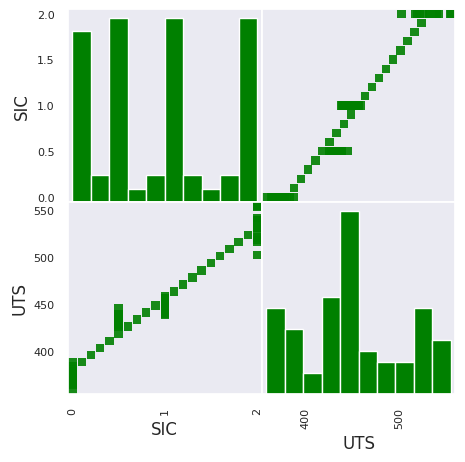

In [8]:
from pandas.plotting import scatter_matrix
#DISPLAY MATRIX - identificar correlacion entre variables
import seaborn as sns
sns.set()

plt.rcParams["axes.grid"] = False

#pd.tools.plotting.scatter_matrix(df, alpha=0.2, c='red', hist_kwds={'color':['burlywood']})

#scatter_matrix(data, alpha=0.2, marker='o', figsize = (12,12), color = 'blue')
scatter_matrix(data, alpha=0.9,marker='s', figsize = (5,5),  c='green', hist_kwds={'color':['green']})

warnings.filterwarnings("ignore")

##Setting inputs - output:

In [9]:
X=data[['SIC']]
Y=data['UTS'].values.reshape(-1, 1)


## Split data

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print('training samples:', X_train.shape[0],  ' test samples:', X_test.shape[0])

training samples: 52  test samples: 13


In [11]:
YTR=np.mean(y_train)
YTR

np.float64(449.12357115384606)

In [12]:
YT=np.mean(y_test)
YT

np.float64(451.5319461538462)

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
from lazypredict.Supervised import LazyRegressor
from sklearn.utils import shuffle

In [15]:
from sklearn.metrics import mean_absolute_error as MAE
reg = LazyRegressor(verbose=0,ignore_warnings=False, custom_metric=None)
models,predictions = reg.fit(X_train, X_test, y_train, y_test)

print(models)

                               Adjusted R-Squared  R-Squared        RMSE  \
Model                                                                      
ExtraTreesRegressor                      0.962901   0.965993   11.083018   
RandomForestRegressor                    0.961709   0.964900   11.259632   
KNeighborsRegressor                      0.960551   0.963838   11.428689   
BaggingRegressor                         0.960394   0.963694   11.451467   
GradientBoostingRegressor                0.958076   0.961570   11.781688   
DecisionTreeRegressor                    0.958073   0.961567   11.782148   
GaussianProcessRegressor                 0.955496   0.959205   12.138804   
AdaBoostRegressor                        0.954250   0.958062   12.307631   
ExtraTreeRegressor                       0.951207   0.955273   12.710395   
Ridge                                    0.950493   0.954619   12.802957   
Lasso                                    0.950486   0.954612   12.803947   
LassoLars   

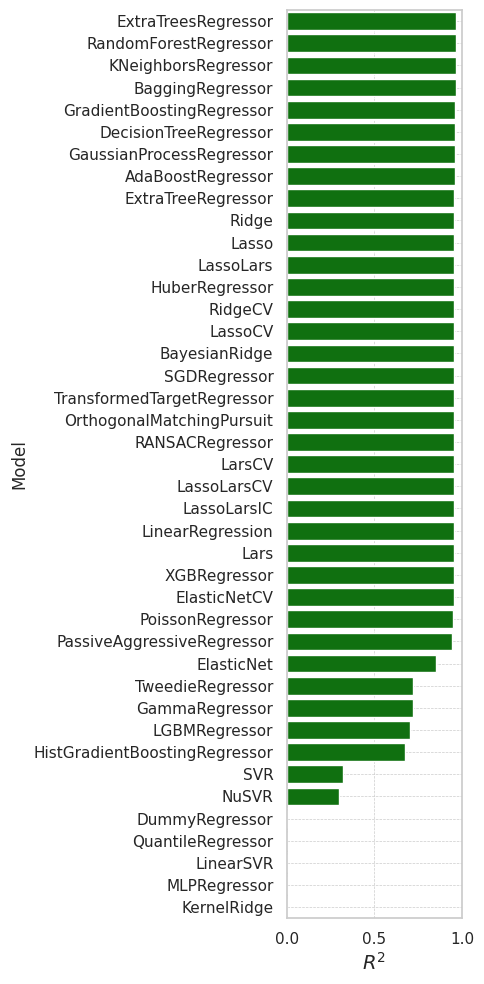

In [16]:
# Plotting
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11

import seaborn as sns
import matplotlib.pyplot as plt

# Re-defining models for independent execution
from lazypredict.Supervised import LazyRegressor
reg = LazyRegressor(verbose=0,ignore_warnings=False, custom_metric=None)
models,predictions = reg.fit(X_train, X_test, y_train, y_test)


plt.style.use('seaborn-v0_8-white')
sns.set_theme(style="whitegrid")

# Corrected to use 'models' DataFrame and apply filtering to 'R-Squared'
models["R-Squared_filtered"] = [0 if i < 0 else i for i in models["R-Squared"] ]
plt.figure(figsize=(5, 10))
ax = sns.barplot(y=models.index, x="R-Squared_filtered", data=models, color='green') # Changed to use 'models' and the new filtered column
ax.set(xlim=(0, 1))
plt.xlabel('$R^2$', fontsize=14)

plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()

plt.savefig('lazy2.png', dpi=300)

plt.show()

# KNN


In [17]:
from sklearn.neighbors import KNeighborsRegressor
#KERNEL
KNN=KNeighborsRegressor(n_neighbors=7)

#START TRAINING
KNN.fit(X_train,y_train)
#PREDICTION

y_train_pred = KNN.predict(X_train)
y_test_pred = KNN.predict(X_test)

y_pred_train = KNN.predict(X_train)
y_pred_test = KNN.predict(X_test)

MSE_train = MSE(y_train, y_train_pred)
MSE_test = MSE(y_test, y_test_pred)
r2_train = R2(y_train, y_train_pred)
r2_test = R2(y_test, y_test_pred)
mae_train = MAE(y_train, y_train_pred)
mae_test = MAE(y_test, y_test_pred)

print('-'*100)
print(f'Error Metrics')
print(f'Training: MAE={mae_train:.4f}, MSE={MSE_train:.4f}, R2={r2_train:.4f}')
print(f'Testing: MAE={mae_test:.4f}, MSE={MSE_test:.4f}, R2={r2_test:.4f}')
print('-'*100)

----------------------------------------------------------------------------------------------------
Error Metrics
Training: MAE=8.2347, MSE=92.8256, R2=0.9659
Testing: MAE=8.6300, MSE=144.9396, R2=0.9599
----------------------------------------------------------------------------------------------------


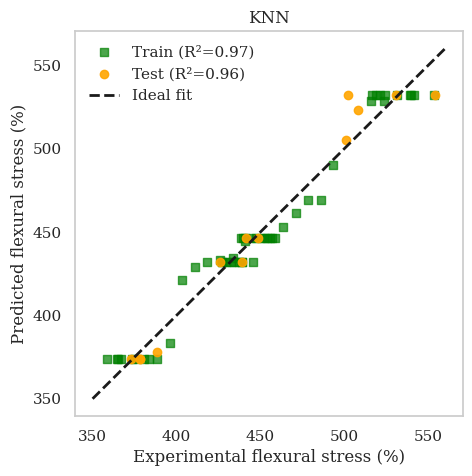

In [18]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11

fig, axes = plt.subplots(1, 1, figsize=(5, 5), sharex=True, sharey=True)

ax = axes
ax.scatter(y_train, y_pred_train, label=f"Train (R²={r2_train:.2f})", alpha=0.7, color='green', marker='s')
ax.scatter(y_test, y_pred_test, label=f"Test (R²={r2_test:.2f})", alpha=0.9, color='orange')
ax.plot([350, 560], [350, 560], 'k--', lw=2, label='Ideal fit')
#ax.plot([10, 40], [10, 40], 'k--', lw=2, label='Ideal fit')

ax.set_title("KNN")
ax.set_xlabel("Experimental flexural stress (%)")
ax.set_ylabel("Predicted flexural stress (%)")


ax.legend(loc='upper left')
ax.grid(False)
plt.show()

# Random Forest Regressor

In [19]:
from sklearn.ensemble import RandomForestRegressor
#KERNEL
RFR=RandomForestRegressor(n_estimators=2000)

#START TRAINING
RFR.fit(X_train,y_train)
#PREDICTION

y_train_pred = RFR.predict(X_train)
y_test_pred = RFR.predict(X_test)

y_pred_train = RFR.predict(X_train)
y_pred_test = RFR.predict(X_test)

MSE_train = MSE(y_train, y_train_pred)
MSE_test = MSE(y_test, y_test_pred)
r2_train = R2(y_train, y_train_pred)
r2_test = R2(y_test, y_test_pred)
mae_train = MAE(y_train, y_train_pred)
mae_test = MAE(y_test, y_test_pred)

print('-'*100)
print(f'Error Metrics')
print(f'Training: MAE={mae_train:.4f}, MSE={MSE_train:.4f}, R2={r2_train:.4f}')
print(f'Testing: MAE={mae_test:.4f}, MSE={MSE_test:.4f}, R2={r2_test:.4f}')
print('-'*100)

----------------------------------------------------------------------------------------------------
Error Metrics
Training: MAE=6.3448, MSE=63.0945, R2=0.9768
Testing: MAE=7.2553, MSE=124.2096, R2=0.9656
----------------------------------------------------------------------------------------------------


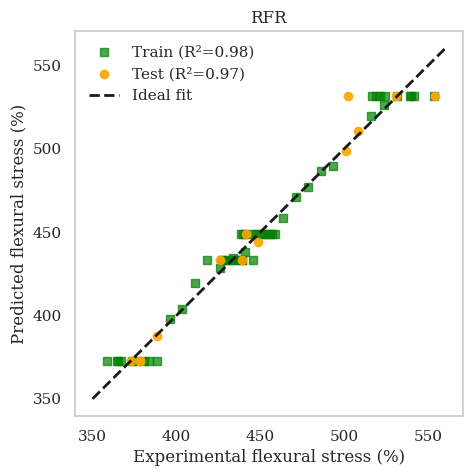

In [20]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11

fig, axes = plt.subplots(1, 1, figsize=(5, 5), sharex=True, sharey=True)

ax = axes
ax.scatter(y_train, y_pred_train, label=f"Train (R²={r2_train:.2f})", alpha=0.7, color='green', marker='s')
ax.scatter(y_test, y_pred_test, label=f"Test (R²={r2_test:.2f})", alpha=0.9, color='orange')
#ax.plot([190, 260], [190, 260], 'k--', lw=2, label='Ideal fit')
ax.plot([350, 560], [350, 560], 'k--', lw=2, label='Ideal fit')

ax.set_title("RFR")
ax.set_xlabel("Experimental flexural stress (%)")
ax.set_ylabel("Predicted flexural stress (%)")


ax.legend(loc='upper left')
ax.grid(False)

plt.show()

# Gaussian Process Regressor

In [21]:
from sklearn.gaussian_process import GaussianProcessRegressor as GPR
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
kernel = C(1.0, (1e-2, 1e2)) * RBF(10, (1e-2, 1e2))

GP=GPR(kernel=kernel, n_restarts_optimizer=20, alpha=0.001, normalize_y=True)

#START TRAINING
GP.fit(X_train, y_train)
#PREDICTION
y_train_pred = GP.predict(X_train)
y_test_pred = GP.predict(X_test)

y_pred_train = GP.predict(X_train)
y_pred_test = GP.predict(X_test)

MSE_train = MSE(y_train, y_train_pred)
MSE_test = MSE(y_test, y_test_pred)
r2_train = R2(y_train, y_train_pred)
r2_test = R2(y_test, y_test_pred)
mae_train = MAE(y_train, y_train_pred)
mae_test = MAE(y_test, y_test_pred)

print('-'*100)
print(f'Error Metrics')
print(f'Training: MAE={mae_train:.4f}, MSE={MSE_train:.4f}, R2={r2_train:.4f}')
print(f'Testing: MAE={mae_test:.4f}, MSE={MSE_test:.4f}, R2={r2_test:.4f}')
print('-'*100)

----------------------------------------------------------------------------------------------------
Error Metrics
Training: MAE=5.7483, MSE=60.1420, R2=0.9779
Testing: MAE=8.6533, MSE=150.8362, R2=0.9582
----------------------------------------------------------------------------------------------------


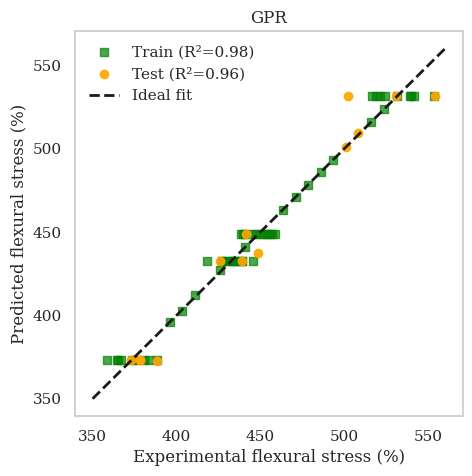

In [22]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11

fig, axes = plt.subplots(1, 1, figsize=(5, 5), sharex=True, sharey=True)

ax = axes
ax.scatter(y_train, y_pred_train, label=f"Train (R²={r2_train:.2f})", alpha=0.7, color='green', marker='s')
ax.scatter(y_test, y_pred_test, label=f"Test (R²={r2_test:.2f})", alpha=0.9, color='orange')
ax.plot([350, 560], [350, 560], 'k--', lw=2, label='Ideal fit')

ax.set_title("GPR")
ax.set_xlabel("Experimental flexural stress (%)")
ax.set_ylabel("Predicted flexural stress (%)")


ax.legend(loc='upper left')
ax.grid(False)

plt.show()

# Cross-validation

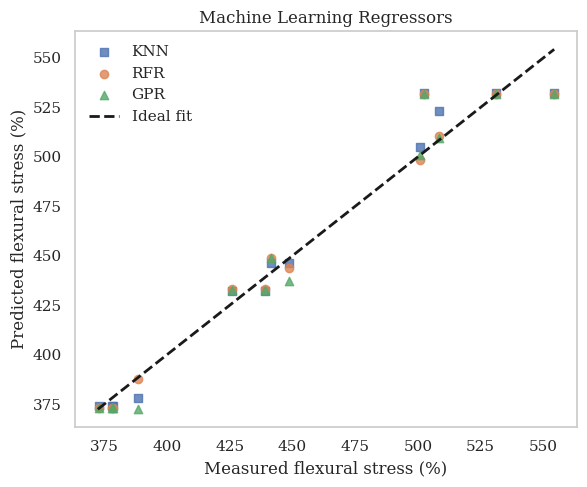

In [23]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11

models = [KNN, RFR, GP]
labels = ['KNN', 'RFR', 'GPR']
markers = ['s', 'o', '^']

fig, ax = plt.subplots(figsize=(6,5))

for model, label, marker in zip(models, labels, markers):
    y_pred = model.predict(X_test)
    ax.scatter(y_test, y_pred, marker=marker, label=label, alpha=0.8)

# Línea de ajuste ideal
lims = [
    min(y_test.min(), *(model.predict(X_test).min() for model in models)),
    max(y_test.max(), *(model.predict(X_test).max() for model in models))
]
ax.plot(lims, lims, 'k--', lw=2, label='Ideal fit')

ax.set_xlabel('Measured flexural stress (%)')
ax.set_ylabel('Predicted flexural stress (%)')
ax.set_title('Machine Learning Regressors')

ax.legend()
ax.grid(False)      # Elimina el grid

plt.tight_layout()
plt.show()

In [24]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error as MSE
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import cross_val_score as CV

import warnings
warnings.filterwarnings('ignore')

models = [ KNN, RFR, GP]
labels = ['KNN', 'RFR', 'GPR']
IMS = []

print("--------------------------------------------------------------")
print("%15s | %8s | %8s | %8s" % ("ML algorithm",  "CV-R2", "CV-MSE", "CV-MAE"))
print("--------------------------------------------------------------")

for mod, label in zip( models, labels):
  y_star_train = mod.predict(X_train)

  scoreR2 = CV(mod, X_train, y_train, cv=5, scoring='r2')
  #print(-1*scoreR2)
  scoreMSE = CV(mod, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
  #print(-1*scoreMSE)
  scoreMAE = CV(mod, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
  #print(-1*scoreMAE)

  print("%15s | %.4f | %.4f | %.4f" % (label,  scoreR2.mean(), -1*scoreMSE.mean(), -1*scoreMAE.mean() ))
print("--------------------------------------------------------------")

--------------------------------------------------------------
   ML algorithm |    CV-R2 |   CV-MSE |   CV-MAE
--------------------------------------------------------------
            KNN | 0.9400 | 143.8562 | 9.6973
            RFR | 0.9617 | 100.0383 | 8.2947
            GPR | 0.9231 | 179.3814 | 10.0583
--------------------------------------------------------------


# LOO

In [25]:
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ----------------------------------------
# Assume your flex dataset is defined as:
# X = np.array([...]).reshape(-1, 1)  # TiO2 wt.%
# y = np.array([...])                 # Flexural strength (MPa)
# ----------------------------------------

loo = LeaveOneOut()

# Fix: Create a dictionary for models using labels and the models list
models_dict = dict(zip(labels, models))

results = {}

for name, model in models_dict.items():
    y_true = []
    y_pred = []

    for train_idx, test_idx in loo.split(X):

        # Split data
        X_train_loo, X_test_loo = X.iloc[train_idx], X.iloc[test_idx]
        y_train_loo, y_test_loo = Y[train_idx], Y[test_idx]

        # Standardize INSIDE CV loop (avoid leakage)
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_loo)
        X_test_scaled = scaler.transform(X_test_loo)

        # Fit model
        # Reshape y_train_loo to be 1D for models like MLPRegressor
        if y_train_loo.ndim > 1 and y_train_loo.shape[1] == 1:
            model.fit(X_train_scaled, y_train_loo.ravel())
        else:
            model.fit(X_train_scaled, y_train_loo)

        # Predict
        prediction = model.predict(X_test_scaled)

        y_true.append(y_test_loo[0])
        y_pred.append(prediction[0])

    # Convert to arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Metrics
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    results[name] = {"MAE": mae, "MSE": mse, "R2": r2}

# Print results
for model_name, metrics in results.items():
    print(f"{model_name} LOOCV Results:")
    print(f"  MAE: {metrics['MAE']:.3f}")
    print(f"  MSE: {metrics['MSE']:.3f}")
    print(f"  R2 : {metrics['R2']:.3f}")
    print("-" * 40)


KNN LOOCV Results:
  MAE: 8.632
  MSE: 117.236
  R2 : 0.960
----------------------------------------
RFR LOOCV Results:
  MAE: 7.355
  MSE: 91.881
  R2 : 0.968
----------------------------------------
GPR LOOCV Results:
  MAE: 8.489
  MSE: 110.480
  R2 : 0.962
----------------------------------------
